In [1]:
import yfinance as yf

In [15]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "^GSPC"]
start_date = "2020-01-01"
end_date = "2026-05-01"
df = yf.download(tickers, start=start_date, end=end_date)['Close']

C:\Users\louis\AppData\Local\Temp\ipykernel_9792\2390848138.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  6 of 6 completed


In [16]:
#yesterday's values
df['AAPL(t-1)'] = df['AAPL'].shift(1)
df['MSFT(t-1)'] = df['MSFT'].shift(1)
df['GOOGL(t-1)'] = df['GOOGL'].shift(1)
df['AMZN(t-1)'] = df['AMZN'].shift(1)
df['TSLA(t-1)'] = df['TSLA'].shift(1)
df['^GSPC(t-1)'] = df['^GSPC'].shift(1)


#"Moving average"
df['AAPL_MA5'] = df['AAPL'].rolling(window=5).mean()
df['MSFT_MA5'] = df['MSFT'].rolling(window=5).mean()
df['GOOGL_MA5'] = df['GOOGL'].rolling(window=5).mean()
df['AMZN_MA5'] = df['AMZN'].rolling(window=5).mean()
df['TSLA_MA5'] = df['TSLA'].rolling(window=5).mean()
df['^GSPC_MA5'] = df['^GSPC'].rolling(window=5).mean()

#set Y Variable  - Next value
df['Target'] = df['AAPL'].shift(-1)
df = df.dropna()
df

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA,^GSPC,AAPL(t-1),MSFT(t-1),GOOGL(t-1),AMZN(t-1),TSLA(t-1),^GSPC(t-1),AAPL_MA5,MSFT_MA5,GOOGL_MA5,AMZN_MA5,TSLA_MA5,^GSPC_MA5,Target
Date,,,,,,,,,,,,,,,,,,,
2020-01-08,73.017822,94.598503,69.676132,151.656326,32.809334,3253.050049,71.861855,149.278534,69.183701,95.343002,31.270666,3237.179932,72.209128,150.801846,68.713680,94.746899,30.480133,3245.842041,74.568771
2020-01-09,74.568771,95.052498,70.407585,153.550980,32.089333,3274.699951,73.017822,151.656326,69.676132,94.598503,32.809334,3253.050049,72.656105,151.080362,69.220593,94.777299,31.161200,3249.212012,74.737358
2020-01-10,74.737358,94.157997,70.862328,152.840439,31.876667,3265.350098,74.568771,153.550980,70.407585,95.052498,32.089333,3274.699951,73.277444,151.595688,69.889468,94.859200,31.629733,3255.312012,76.334099
2020-01-13,76.334099,94.565002,71.411293,154.678299,34.990665,3288.129883,74.737358,152.840439,70.862328,94.157997,31.876667,3265.350098,74.103981,152.400916,70.308208,94.743401,32.607333,3263.681982,75.303345
2020-01-14,75.303345,93.472000,70.943153,153.588806,35.861332,3283.149902,76.334099,154.678299,71.411293,94.565002,34.990665,3288.129883,74.792279,153.262970,70.660098,94.369200,33.525466,3272.875977,74.980621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23,273.178314,255.080002,338.890015,415.750000,373.720001,7108.399902,272.918579,432.920013,339.320007,255.360001,387.510010,7137.899902,270.960364,422.738007,337.920007,251.838000,388.154004,7109.101953,270.810486
2026-04-24,270.810486,263.989990,344.399994,424.619995,376.299988,7165.080078,273.178314,415.750000,338.890015,255.080002,373.720001,7108.399902,271.126208,423.104004,338.464008,254.523999,383.290002,7116.905957,267.363647
2026-04-27,267.363647,261.119995,350.339996,424.820007,378.670013,7173.910156,270.810486,424.619995,344.399994,263.989990,376.299988,7165.080078,270.039209,424.454004,341.048004,257.091998,380.524005,7129.859961,270.460815


## Step 4 Ridge regression : 
- import all the required libraries
- define features and target variables
- train test split
- apply ridge regression
- get intercept and coeff for ridge regression
- Predict using ridge regression
- create a dataframe with actual and predicted values
- plot
- evaluate the model (r², mse, rmse)

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
X = df.drop(columns=['Target', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', '^GSPC'])
Y = df['Target']

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, shuffle=False)

In [21]:
Ridge_model = Ridge(alpha=0.4)
Ridge_model.fit(X_train, Y_train) #training the model

Ridge(alpha=0.4)

In [22]:
coefficients = Ridge_model.coef_
intercept = Ridge_model.intercept_
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})
print(coeff_df)

       Feature  Coefficient
0    AAPL(t-1)     0.626376
1    MSFT(t-1)    -0.053911
2   GOOGL(t-1)    -0.193391
3    AMZN(t-1)     0.123984
4    TSLA(t-1)     0.000795
5   ^GSPC(t-1)     0.007780
6     AAPL_MA5     0.341833
7     MSFT_MA5     0.072972
8    GOOGL_MA5     0.201162
9     AMZN_MA5    -0.125728
10    TSLA_MA5    -0.000470
11   ^GSPC_MA5    -0.008541


In [23]:
y_pred = Ridge_model.predict(X_test)

In [24]:
results_df = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred})
print(results_df)

                Actual   Predicted
Date                              
2025-09-11  233.409668  228.819908
2025-09-12  236.032242  230.978509
2025-09-15  237.478149  233.489836
2025-09-16  238.315796  234.224985
2025-09-17  237.208908  237.056393
...                ...         ...
2026-04-23  270.810486  270.503387
2026-04-24  267.363647  271.190477
2026-04-27  270.460815  269.525790
2026-04-28  269.921326  266.637088
2026-04-29  271.100250  267.905723

[159 rows x 2 columns]


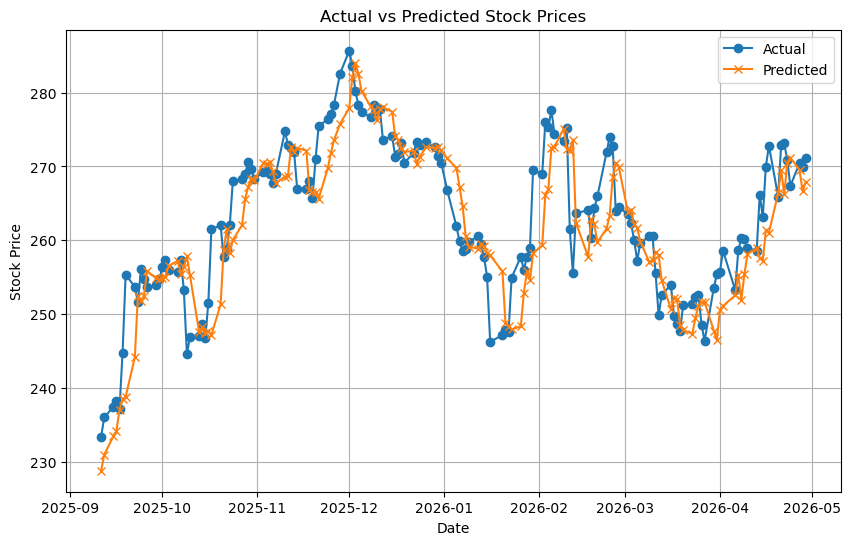

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(Y_test.index, Y_test.values, label='Actual', marker='o')
plt.plot(Y_test.index, y_pred, label='Predicted', marker='x')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid()
plt.show()

In [26]:
print("R² Score:", r2_score(Y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(Y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(Y_test, y_pred)))

R² Score: 0.7413952553661635
Mean Squared Error: 28.981343686664925
Root Mean Squared Error: 5.383432333248457
